# Baseline BETO (cabeza congelada) — config default

In [ ]:
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

In [ ]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

In [ ]:
%cd /content/BETO_HUMOR

In [1]:
import os
import re
import pandas as pd
from transformers import AutoTokenizer

from betohumor.config import DataConfig, BetoConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split, HahaDataset
from betohumor.models.beto import build_beto
from betohumor.train import train_model
from betohumor.metrics import get_best_macro_f1_from_history, get_training_history
from betohumor.plots import plot_training_curves, plot_grid_search_comparison

/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos: versión con hashtags y versión sin hashtags

In [2]:
def remove_hashtags(text):
    return re.sub(r"#\w+", "", text).strip()

data_config = DataConfig(data_path="../data/raw/haha_2019_train.csv")
beto_config = BetoConfig() 
set_seed(data_config.seed)

text_col  = data_config.text_col
label_col = data_config.label_col

df_train, df_val, df_test = load_and_split(data_config)

df_train_no = df_train.copy()
df_val_no   = df_val.copy()
df_test_no  = df_test.copy()
for df in (df_train_no, df_val_no, df_test_no):
    df[text_col] = df[text_col].apply(remove_hashtags)

ejemplo_idx = df_train[df_train[text_col].str.contains('#')].index[0]
print('Con hashtags:', df_train.loc[ejemplo_idx, text_col])
print('Sin hashtags:', df_train_no.loc[ejemplo_idx, text_col])

Train: 19197 | Val: 2397 | Test: 2400
Con hashtags: Kennia está molesta. No importa cuándo leas este tuit. #MasterChefMx
Sin hashtags: Kennia está molesta. No importa cuándo leas este tuit.


## 2. Tokenizer
Se usa el mismo tokenizer para ambas corridas (no cambia con/sin hashtags).

In [3]:
tokenizer = AutoTokenizer.from_pretrained(beto_config.base_model)

## 3. Datasets (con hashtags)

In [4]:
train_dataset = HahaDataset(df_train, tokenizer, data_config)
val_dataset   = HahaDataset(df_val,   tokenizer, data_config)
test_dataset  = HahaDataset(df_test,  tokenizer, data_config)

## 4. Entrenamiento (con hashtags, config default)

In [7]:
model = build_beto(beto_config)

trainer = train_model(
    model, train_dataset, val_dataset, beto_config,
    output_dir='../results/beto_b/with_hashtags',
    seed=data_config.seed,
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 56316.65it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECT

Baseline — entrenables: 592,130 / 109,852,418
{'loss': '0.6508', 'grad_norm': '1.008', 'learning_rate': '9.933e-06', 'epoch': '1'}
{'eval_loss': '0.5978', 'eval_accuracy': '0.7484', 'eval_macro_f1': '0.7366', 'eval_runtime': '3.549', 'eval_samples_per_second': '675.5', 'eval_steps_per_second': '5.354', 'epoch': '1'}
  Época 1 | val_loss=0.5978 | macro_f1=0.7366 | accuracy=0.7484


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.95it/s]
/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.5396', 'grad_norm': '0.8105', 'learning_rate': '1.993e-05', 'epoch': '2'}
{'eval_loss': '0.4993', 'eval_accuracy': '0.776', 'eval_macro_f1': '0.7677', 'eval_runtime': '3.605', 'eval_samples_per_second': '664.9', 'eval_steps_per_second': '5.27', 'epoch': '2'}
  Época 2 | val_loss=0.4993 | macro_f1=0.7677 | accuracy=0.7760


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.51it/s]
/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.58it/s]
/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.3731', 'grad_norm': '0.831', 'learning_rate': '9.89e-05', 'epoch': '11'}
{'eval_loss': '0.392', 'eval_accuracy': '0.8027', 'eval_macro_f1': '0.7987', 'eval_runtime': '3.62', 'eval_samples_per_second': '662.2', 'eval_steps_per_second': '5.249', 'epoch': '11'}
  Época 11 | val_loss=0.3920 | macro_f1=0.7987 | accuracy=0.8027


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.44it/s]

{'train_runtime': '408.9', 'train_samples_per_second': '4694', 'train_steps_per_second': '36.68', 'train_loss': '0.4311', 'epoch': '11'}



There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.L

## 5. Métricas y curva (con hashtags)

Macro F1 (con hashtags): 0.8117


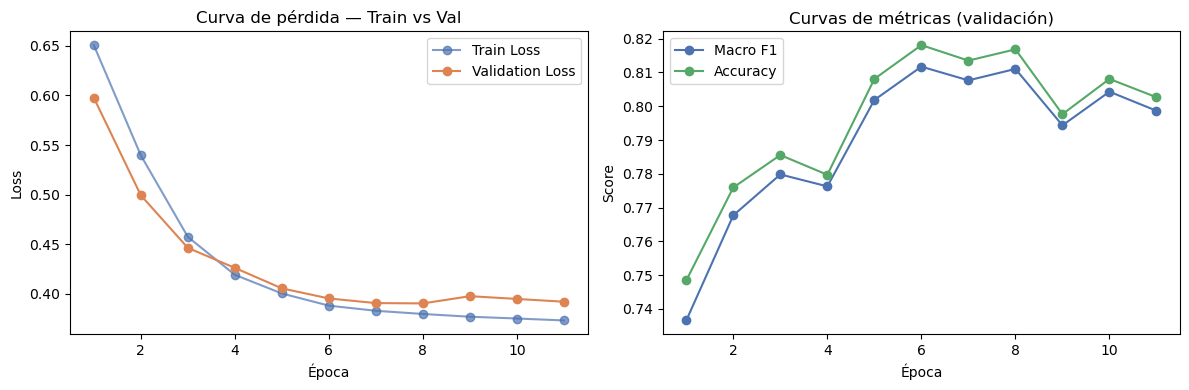

In [8]:
history_with = get_training_history(trainer)
macro_f1_with = get_best_macro_f1_from_history(trainer)

print(f"Macro F1 (con hashtags): {macro_f1_with:.4f}")
fig = plot_training_curves(history_with)
# fig.savefig('../results/figures/curve_beto_default_with_hashtags.png', dpi=150)

---
# Repetimos todo el proceso, ahora SIN hashtags
---

## 6. Datasets (sin hashtags)

In [9]:
train_dataset_no = HahaDataset(df_train_no, tokenizer, data_config)
val_dataset_no   = HahaDataset(df_val_no,   tokenizer, data_config)
test_dataset_no  = HahaDataset(df_test_no,  tokenizer, data_config)

## 7. Entrenamiento (sin hashtags, config default)

In [15]:
model_no = build_beto(beto_config)

trainer_no = train_model(
    model_no, train_dataset_no, val_dataset_no, beto_config,
    output_dir='../results/beto_b/no_hashtags',
    seed=data_config.seed,
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 63859.49it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECT

Baseline — entrenables: 592,130 / 109,852,418


/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.6507', 'grad_norm': '1.132', 'learning_rate': '9.933e-06', 'epoch': '1'}
{'eval_loss': '0.5938', 'eval_accuracy': '0.7639', 'eval_macro_f1': '0.7535', 'eval_runtime': '3.636', 'eval_samples_per_second': '659.2', 'eval_steps_per_second': '5.225', 'epoch': '1'}
  Época 1 | val_loss=0.5938 | macro_f1=0.7535 | accuracy=0.7639


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.47it/s]
/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.22it/s]
/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.3768', 'grad_norm': '1.056', 'learning_rate': '9.667e-05', 'epoch': '13'}
{'eval_loss': '0.3877', 'eval_accuracy': '0.8139', 'eval_macro_f1': '0.808', 'eval_runtime': '3.585', 'eval_samples_per_second': '668.6', 'eval_steps_per_second': '5.3', 'epoch': '13'}
  Época 13 | val_loss=0.3877 | macro_f1=0.8080 | accuracy=0.8139


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.94it/s]

{'train_runtime': '492.8', 'train_samples_per_second': '3895', 'train_steps_per_second': '30.44', 'train_loss': '0.4244', 'epoch': '13'}



There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.L

## 8. Métricas y curva (sin hashtags)

Macro F1 (sin hashtags): 0.8117


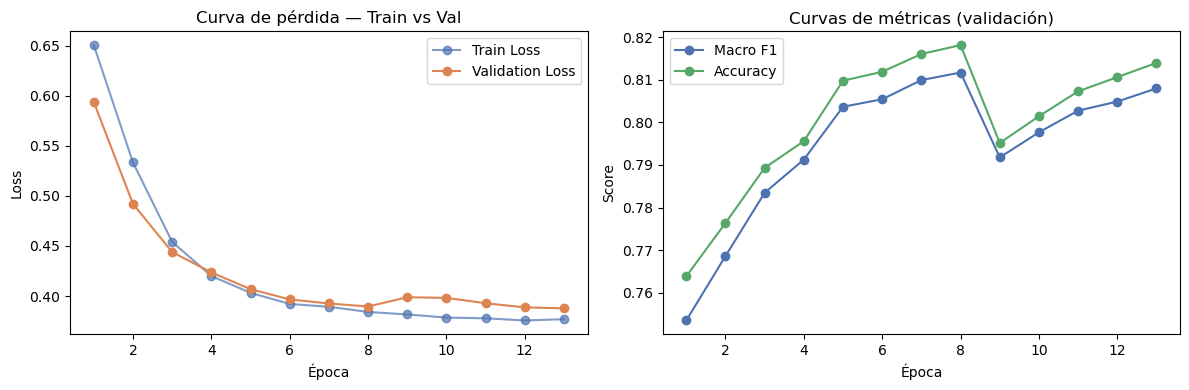

In [16]:
history_no = get_training_history(trainer_no)
macro_f1_no = get_best_macro_f1_from_history(trainer_no)

print(f"Macro F1 (sin hashtags): {macro_f1_no:.4f}")
fig = plot_training_curves(history_no)

---
## 9. Comparación con vs. sin hashtags
---

In [17]:
diferencia = macro_f1_with - macro_f1_no
diferencia_pct = round(diferencia / macro_f1_with * 100, 2)

df_ablation = pd.DataFrame([{
    'modelo': 'BETO baseline (default)',
    'macro_f1_con_hashtags': macro_f1_with,
    'macro_f1_sin_hashtags': macro_f1_no,
    'diferencia': diferencia,
    'diferencia_pct': diferencia_pct,
}])

os.makedirs('../results/beto_default', exist_ok=True)
df_ablation.to_csv('../results/beto_b/analysis_hashtags.csv', index=False)
df_ablation

,modelo,macro_f1_con_hashtags,macro_f1_sin_hashtags,diferencia,diferencia_pct
0,BETO baseline (default),0.811733,0.811673,0.00006,0.01


## 10. Guardar resultados

In [18]:
os.makedirs("../results/beto_b", exist_ok=True)
df_ablation.to_csv("../results/beto_b/metrics.csv", index=False)